# 04 · Two-Stage Model Comparison: U-Net vs DeepLabv3 (ResNet-50)

**CSE445 · Road Surface Crack Detection & Segmentation**

### Two-Stage Fine-Tuning Methodology:
- **Stage 1 (Pre-training on Macro Close-Up Cracks)**:
  - Dataset: `stage1_train.csv` / `closeup_train.csv` (2,346 samples, 502 val samples).
  - Batch Size: `64`, Workers: `8` (with `persistent_workers=True`).
  - Objective: Learn rich asphalt surface features, fissure textures, and high-frequency crack patterns.
- **Stage 2 (Fine-Tuning on Dashcam Road Survey Imagery)**:
  - Dataset: `train.csv` / `dashcam_train.csv` (1,982 samples, 424 val samples).
  - Batch Size: `64`, Workers: `8` (with `persistent_workers=True`).
  - Objective: Adapt the pre-trained weights to handle perspective distortion, thin crack scale, lighting variations, and vehicle vibrations.
- **Fair Head-to-Head Comparison**:
  - Held-out test set: `test.csv` / `dashcam_test.csv` (426 samples).
  - Compare **Two-Stage U-Net** vs. **Two-Stage DeepLabv3** across IoU, Dice (F1), Precision, Recall, Pixel Accuracy, Model Size, and Inference Latency (FPS).


In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path

# Suppress albumentations update check
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

try:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/Road_Damage_Project'
    os.environ['RUN_ENV'] = 'colab'
except ImportError:
    curr = Path.cwd()
    REPO = str(curr if (curr / 'config.py').exists() else curr.parent)
    os.environ['RUN_ENV'] = 'local'

if REPO not in sys.path:
    sys.path.insert(0, REPO)
print('Repo root:', REPO)


Repo root: d:\Road_Damage_Project


In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader
from tqdm import tqdm

import config
from support.shared.dataset import SegmentationDataset
from support.shared.transforms import get_train_transforms, get_val_transforms
from support.shared.deeplabv3 import DeepLabV3Segmentation
from support.shared.unet import UNet
from support.shared.losses import BCEDiceLoss
from support.shared.trainer import Trainer
from support.shared.metrics import compute_all_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_workers = 8
persistent_workers = True if num_workers > 0 else False

print('PyTorch version   :', torch.__version__)
print('Device            :', device)
print('DataLoader workers:', num_workers, f'(persistent={persistent_workers})')
if torch.cuda.is_available():
    print('GPU               :', torch.cuda.get_device_name(0))


d:\anaconda3\envs\Thesis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version   : 2.10.0+cu130
Device            : cuda
DataLoader workers: 8 (persistent=True)
GPU               : NVIDIA GeForce RTX 5070 Ti


---
## 1. Stage 1: DeepLabv3 Pre-training on Close-Up Dataset
Pre-train DeepLabv3 (ResNet-50) on high-contrast macro crack images (`stage1_train.csv` = 2,346 samples, batch_size = 64, workers = 8).

In [3]:
cfg_s1 = config.CRACK_DEEPLABV3_STAGE1.copy()
img_size = (config.IMG_HEIGHT, config.IMG_WIDTH)

# Stage 1 Close-up manifests
s1_train_csv = config.CRACK_SPLIT_DIR / 'stage1_train.csv'
s1_val_csv   = config.CRACK_SPLIT_DIR / 'stage1_val.csv'
if not s1_train_csv.exists():
    s1_train_csv = config.CRACK_SPLIT_DIR / 'closeup_train.csv'
    s1_val_csv   = config.CRACK_SPLIT_DIR / 'closeup_val.csv'

train_ds_s1 = SegmentationDataset(s1_train_csv, transform=get_train_transforms(img_size))
val_ds_s1   = SegmentationDataset(s1_val_csv,   transform=get_val_transforms(img_size))

train_loader_s1 = DataLoader(
    train_ds_s1, batch_size=cfg_s1['batch_size'], shuffle=True,
    num_workers=num_workers, persistent_workers=persistent_workers, pin_memory=torch.cuda.is_available()
)
val_loader_s1 = DataLoader(
    val_ds_s1, batch_size=cfg_s1['batch_size'], shuffle=False,
    num_workers=num_workers, persistent_workers=persistent_workers, pin_memory=torch.cuda.is_available()
)

print(f'Stage 1 Close-Up Train: {len(train_ds_s1):,} samples ({len(train_loader_s1)} batches @ batch_size={cfg_s1["batch_size"]})')
print(f'Stage 1 Close-Up Val  : {len(val_ds_s1):,} samples ({len(val_loader_s1)} batches @ batch_size={cfg_s1["batch_size"]})')


Stage 1 Close-Up Train: 2,346 samples (37 batches @ batch_size=64)
Stage 1 Close-Up Val  : 502 samples (8 batches @ batch_size=64)


In [4]:
# Instantiate DeepLabv3 Stage 1 Model & Trainer
model_dl_s1 = DeepLabV3Segmentation(
    in_channels=cfg_s1['in_channels'],
    out_channels=cfg_s1['out_channels'],
    backbone=cfg_s1.get('backbone', 'resnet50'),
    pretrained=cfg_s1.get('pretrained', True)
)
print(f'DeepLabv3 parameters: {model_dl_s1.count_parameters():,}')

loss_fn_s1 = BCEDiceLoss(bce_weight=cfg_s1['bce_weight'], dice_weight=cfg_s1['dice_weight'])
trainer_dl_s1 = Trainer(model_dl_s1, loss_fn_s1, cfg_s1, train_loader_s1, val_loader_s1)

# Set DRY_RUN = True to test a quick 1-epoch pass, or DRY_RUN = False for full training
DRY_RUN_S1 = False
s1_ckpt = config.EXP_DIR / cfg_s1['run_name'] / 'best_model.pth'

if s1_ckpt.exists() and not DRY_RUN_S1:
    print(f'Found existing Stage 1 DeepLabv3 checkpoint: {s1_ckpt}')
    print('Ready to proceed to Stage 2 Fine-Tuning.')
else:
    print('Training DeepLabv3 Stage 1...')
    history_s1 = trainer_dl_s1.fit(n_epochs=1 if DRY_RUN_S1 else None)


DeepLabv3 parameters: 41,993,794
[Trainer] Using device: cuda
[Trainer] Mixed precision (AMP) enabled.
[Trainer] Config snapshot -> D:\Road_Damage_Project\experiments\crack_stage1_deeplabv3\config_snapshot.json
Found existing Stage 1 DeepLabv3 checkpoint: D:\Road_Damage_Project\experiments\crack_stage1_deeplabv3\best_model.pth
Ready to proceed to Stage 2 Fine-Tuning.


---
## 2. Stage 2: DeepLabv3 Fine-Tuning on Dashcam / Survey Dataset
Load Stage 1 pre-trained weights into DeepLabv3 and fine-tune on Dashcam imagery (`train.csv` = 1,982 samples, batch_size = 64, workers = 8).

In [5]:
cfg_s2 = config.CRACK_DEEPLABV3_STAGE2.copy()

# Stage 2 Dashcam manifests
s2_train_csv = config.CRACK_SPLIT_DIR / 'train.csv'
s2_val_csv   = config.CRACK_SPLIT_DIR / 'val.csv'
if not s2_train_csv.exists():
    s2_train_csv = config.CRACK_SPLIT_DIR / 'dashcam_train.csv'
    s2_val_csv   = config.CRACK_SPLIT_DIR / 'dashcam_val.csv'

train_ds_s2 = SegmentationDataset(s2_train_csv, transform=get_train_transforms(img_size))
val_ds_s2   = SegmentationDataset(s2_val_csv,   transform=get_val_transforms(img_size))

train_loader_s2 = DataLoader(
    train_ds_s2, batch_size=cfg_s2['batch_size'], shuffle=True,
    num_workers=num_workers, persistent_workers=persistent_workers, pin_memory=torch.cuda.is_available()
)
val_loader_s2 = DataLoader(
    val_ds_s2, batch_size=cfg_s2['batch_size'], shuffle=False,
    num_workers=num_workers, persistent_workers=persistent_workers, pin_memory=torch.cuda.is_available()
)

print(f'Stage 2 Dashcam Train: {len(train_ds_s2):,} samples ({len(train_loader_s2)} batches @ batch_size={cfg_s2["batch_size"]})')
print(f'Stage 2 Dashcam Val  : {len(val_ds_s2):,} samples ({len(val_loader_s2)} batches @ batch_size={cfg_s2["batch_size"]})')


Stage 2 Dashcam Train: 1,982 samples (31 batches @ batch_size=64)
Stage 2 Dashcam Val  : 424 samples (7 batches @ batch_size=64)


In [6]:
# Build Stage 2 DeepLabv3 Model and transfer Stage 1 weights
model_dl_s2 = DeepLabV3Segmentation(
    in_channels=cfg_s2['in_channels'],
    out_channels=cfg_s2['out_channels'],
    backbone=cfg_s2.get('backbone', 'resnet50'),
    pretrained=False
)

stage1_dl_ckpt = config.EXP_DIR / cfg_s1['run_name'] / 'best_model.pth'
if stage1_dl_ckpt.exists():
    print(f'Transferring Stage 1 DeepLabv3 weights from: {stage1_dl_ckpt}')
    state = torch.load(stage1_dl_ckpt, map_location=device)
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    model_dl_s2.load_state_dict(state, strict=False)
    print('[OK] Stage 1 weights loaded successfully into DeepLabv3!')
else:
    print('[!] Note: No Stage 1 checkpoint found. Using initialized model.')

loss_fn_s2 = BCEDiceLoss(bce_weight=cfg_s2['bce_weight'], dice_weight=cfg_s2['dice_weight'])
trainer_dl_s2 = Trainer(model_dl_s2, loss_fn_s2, cfg_s2, train_loader_s2, val_loader_s2)

# Set DRY_RUN = True for a 1-epoch sanity check
DRY_RUN_S2 = False
stage2_dl_ckpt = config.EXP_DIR / cfg_s2['run_name'] / 'best_model.pth'

if stage2_dl_ckpt.exists() and not DRY_RUN_S2:
    print(f'Found existing Stage 2 DeepLabv3 fine-tuned checkpoint: {stage2_dl_ckpt}')
else:
    print('Fine-tuning DeepLabv3 Stage 2...')
    history_s2 = trainer_dl_s2.fit(n_epochs=1 if DRY_RUN_S2 else None)


Transferring Stage 1 DeepLabv3 weights from: D:\Road_Damage_Project\experiments\crack_stage1_deeplabv3\best_model.pth
[OK] Stage 1 weights loaded successfully into DeepLabv3!
[Trainer] Using device: cuda
[Trainer] Mixed precision (AMP) enabled.
[Trainer] Resuming from checkpoint: D:\Road_Damage_Project\experiments\crack_stage2_deeplabv3_finetuned\best_model.pth
[Trainer] Resumed model state. Baseline best Val IoU: 0.1353, Start epoch: 47
[Trainer] Config snapshot -> D:\Road_Damage_Project\experiments\crack_stage2_deeplabv3_finetuned\config_snapshot.json
Found existing Stage 2 DeepLabv3 fine-tuned checkpoint: D:\Road_Damage_Project\experiments\crack_stage2_deeplabv3_finetuned\best_model.pth


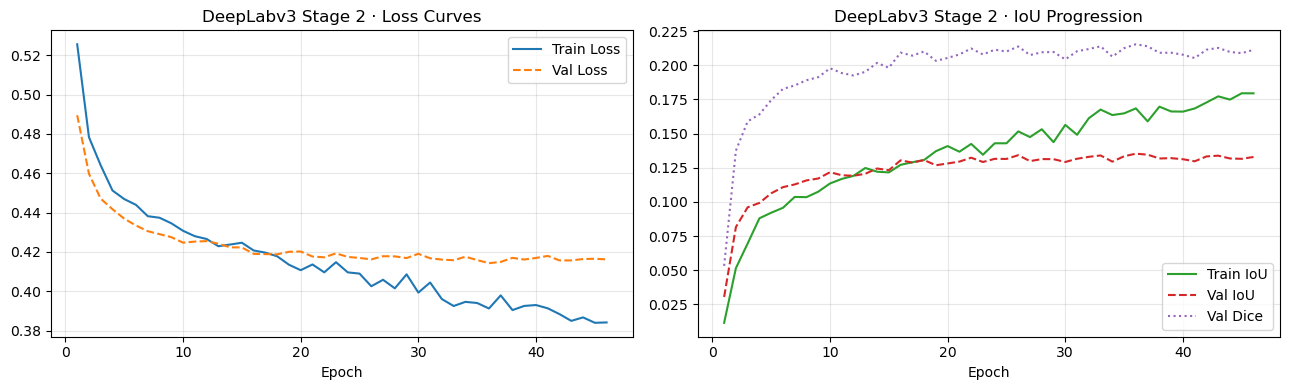

In [7]:
# Plot DeepLabv3 Fine-Tuning Curves
log_path = config.EXP_DIR / cfg_s2['run_name'] / 'train_log.csv'
if log_path.exists():
    df_s2 = pd.read_csv(log_path)
elif 'history_s2' in locals() and history_s2:
    df_s2 = pd.DataFrame(history_s2)
else:
    df_s2 = None

if df_s2 is not None and not df_s2.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df_s2['epoch'], df_s2['train_loss'], label='Train Loss', color='tab:blue')
    axes[0].plot(df_s2['epoch'], df_s2['val_loss'],   label='Val Loss',   color='tab:orange', linestyle='--')
    axes[0].set_title('DeepLabv3 Stage 2 · Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_s2['epoch'], df_s2['train_iou'], label='Train IoU', color='tab:green')
    axes[1].plot(df_s2['epoch'], df_s2['val_iou'],   label='Val IoU',   color='tab:red', linestyle='--')
    axes[1].plot(df_s2['epoch'], df_s2['val_dice'],  label='Val Dice',  color='tab:purple', linestyle=':')
    axes[1].set_title('DeepLabv3 Stage 2 · IoU Progression')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


---
## 3. Head-to-Head Comparison: Two-Stage U-Net vs Two-Stage DeepLabv3
We load both models at their best fine-tuned checkpoints and evaluate on the held-out Dashcam test set (`test.csv` = 426 samples).

In [8]:
# 1. Load Held-Out Test DataLoader
test_csv = config.CRACK_SPLIT_DIR / 'test.csv'
if not test_csv.exists():
    test_csv = config.CRACK_SPLIT_DIR / 'dashcam_test.csv'

test_ds = SegmentationDataset(test_csv, transform=get_val_transforms(img_size))
test_loader = DataLoader(
    test_ds, batch_size=cfg_s2['batch_size'], shuffle=False,
    num_workers=num_workers, persistent_workers=persistent_workers, pin_memory=torch.cuda.is_available()
)
print(f'Held-Out Test Dataset: {len(test_ds):,} samples ({len(test_loader)} batches)')

# 2. Load Two-Stage U-Net Best Checkpoint
unet_model = UNet(in_channels=3, out_channels=1, base_features=32).to(device)
unet_candidates = [
    config.EXP_DIR / 'crack_stage2_unet_finetuned' / 'best_model.pth',
    config.EXP_DIR / 'crack_stage1_unet' / 'best_model.pth',
    config.EXP_DIR / 'crack_unet_run1' / 'best_model.pth',
]
unet_loaded = False
for p in unet_candidates:
    if p.exists():
        st = torch.load(p, map_location=device)
        if isinstance(st, dict) and 'model_state_dict' in st:
            st = st['model_state_dict']
        unet_model.load_state_dict(st)
        print(f'Loaded Two-Stage U-Net from: {p}')
        unet_loaded = True
        break
unet_model.eval()

# 3. Load Two-Stage DeepLabv3 Best Checkpoint
deeplab_eval_model = DeepLabV3Segmentation(in_channels=3, out_channels=1, backbone='resnet50', pretrained=False).to(device)
dl_candidates = [
    config.EXP_DIR / 'crack_stage2_deeplabv3_finetuned' / 'best_model.pth',
    config.EXP_DIR / 'crack_stage1_deeplabv3' / 'best_model.pth',
    config.EXP_DIR / 'crack_deeplabv3_run1' / 'best_model.pth',
]
dl_loaded = False
for p in dl_candidates:
    if p.exists():
        st = torch.load(p, map_location=device)
        if isinstance(st, dict) and 'model_state_dict' in st:
            st = st['model_state_dict']
        deeplab_eval_model.load_state_dict(st, strict=False)
        print(f'Loaded Two-Stage DeepLabv3 from: {p}')
        dl_loaded = True
        break
if not dl_loaded:
    print('[!] Note: Using current in-memory DeepLabv3 model instance.')
    deeplab_eval_model = model_dl_s2.to(device)
deeplab_eval_model.eval()

# 4. Full Evaluation with Metrics, Model Parameters, and Latency Profiling
def evaluate_model_full(model_obj, loader, threshold=0.35):
    totals = {'iou': 0.0, 'dice': 0.0, 'pixel_acc': 0.0, 'precision': 0.0, 'recall': 0.0}
    n_batches = len(loader)
    n_images = 0
    torch.cuda.empty_cache()
    t_start = time.time()
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model_obj(imgs)
            m = compute_all_metrics(preds, masks, threshold=threshold)
            for k in totals: totals[k] += m[k]
            n_images += imgs.size(0)
            
    total_time = time.time() - t_start
    avg_m = {k: float(v / n_batches) for k, v in totals.items()}
    avg_m['latency_ms'] = float((total_time / n_images) * 1000.0)
    avg_m['fps'] = float(n_images / total_time)
    avg_m['params_M'] = float(model_obj.count_parameters() / 1e6)
    return avg_m

print('\nEvaluating models on held-out test set (threshold = 0.35)...')
eval_th = 0.35
res_unet = evaluate_model_full(unet_model, test_loader, threshold=eval_th)
res_dl   = evaluate_model_full(deeplab_eval_model, test_loader, threshold=eval_th)

df_comp = pd.DataFrame([res_unet, res_dl], index=['Two-Stage U-Net', 'Two-Stage DeepLabv3 (ResNet-50)'])
print('\n' + '='*80)
print('  HEAD-TO-HEAD MODEL COMPARISON: TWO-STAGE U-NET vs TWO-STAGE DEEPLABV3')
print('='*80)
print(df_comp[['iou', 'dice', 'precision', 'recall', 'pixel_acc', 'params_M', 'latency_ms', 'fps']].round(4))
print('='*80)


Held-Out Test Dataset: 426 samples (7 batches)
Loaded Two-Stage U-Net from: D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth
Loaded Two-Stage DeepLabv3 from: D:\Road_Damage_Project\experiments\crack_stage2_deeplabv3_finetuned\best_model.pth

Evaluating models on held-out test set (threshold = 0.35)...

  HEAD-TO-HEAD MODEL COMPARISON: TWO-STAGE U-NET vs TWO-STAGE DEEPLABV3
                                    iou    dice  precision  recall  pixel_acc  \
Two-Stage U-Net                  0.2011  0.2976     0.3145  0.3720      0.995   
Two-Stage DeepLabv3 (ResNet-50)  0.1382  0.2200     0.2093  0.3246      0.993   

                                 params_M  latency_ms      fps  
Two-Stage U-Net                    7.8496     88.8408  11.2561  
Two-Stage DeepLabv3 (ResNet-50)   39.6337     31.0931  32.1615  


---
## 4. Comparative Visualizations & Trade-Off Analysis

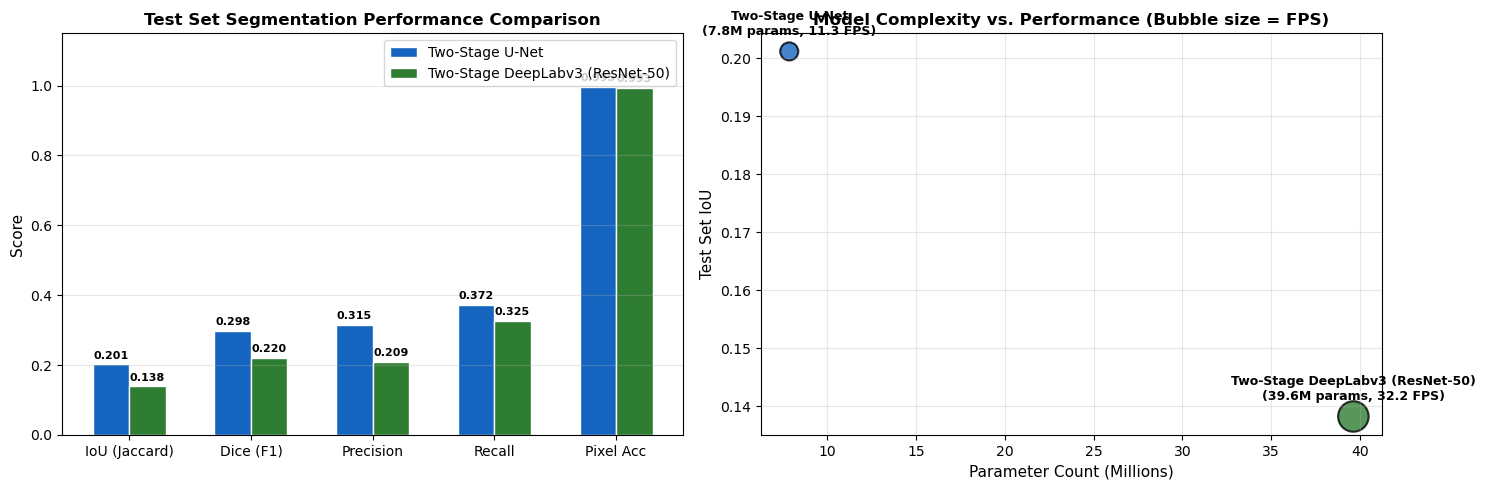

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Metric Comparison Bar Chart
metric_cols = ['iou', 'dice', 'precision', 'recall', 'pixel_acc']
df_comp[metric_cols].T.plot(kind='bar', ax=axes[0], color=['#1565C0', '#2E7D32'], width=0.6, edgecolor='white')
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Test Set Segmentation Performance Comparison', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(['IoU (Jaccard)', 'Dice (F1)', 'Precision', 'Recall', 'Pixel Acc'], rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')
axes[0].legend(loc='upper right')

# 2. Parameters vs Latency Trade-off
comp_labels = list(df_comp.index)
axes[1].scatter(df_comp['params_M'], df_comp['iou'], s=[df_comp.loc[m, 'fps']*15 for m in comp_labels], color=['#1565C0', '#2E7D32'], alpha=0.8, edgecolors='black', linewidth=1.5)
for i, txt in enumerate(comp_labels):
    axes[1].annotate(f"{txt}\n({df_comp.loc[txt, 'params_M']:.1f}M params, {df_comp.loc[txt, 'fps']:.1f} FPS)", 
                     (df_comp.loc[txt, 'params_M'], df_comp.loc[txt, 'iou']),
                     textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Parameter Count (Millions)', fontsize=11)
axes[1].set_ylabel('Test Set IoU', fontsize=11)
axes[1].set_title('Model Complexity vs. Performance (Bubble size = FPS)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 5. Qualitative Visual Comparison on Test Samples

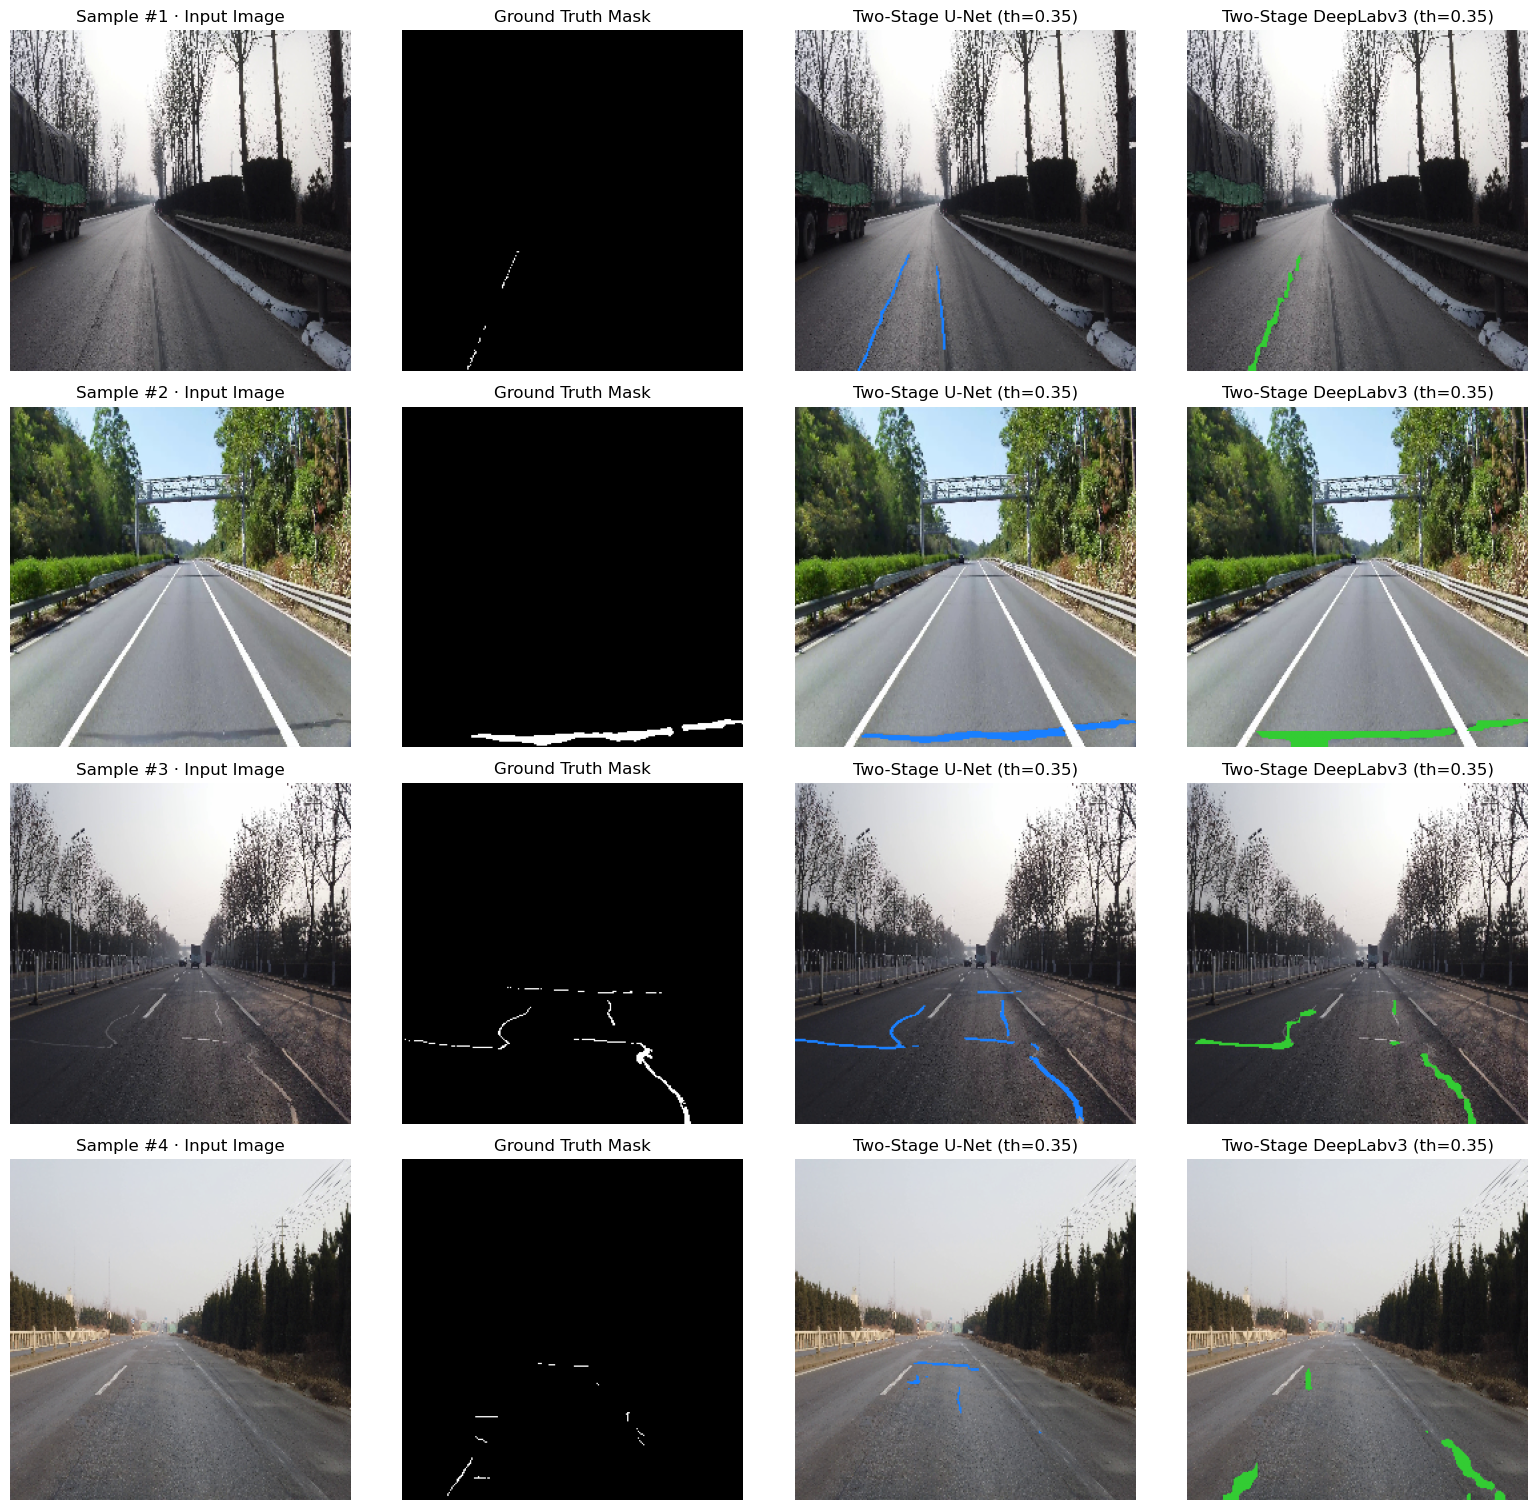

In [10]:
n_samples = 4
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 3.8 * n_samples))

for i in range(n_samples):
    idx = i * (len(test_ds) // n_samples)
    img_t, mask_t = test_ds[idx]
    
    with torch.no_grad():
        pred_unet = unet_model(img_t.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        pred_dl   = deeplab_eval_model(img_t.unsqueeze(0).to(device)).squeeze().cpu().numpy()
    
    # Denormalize image
    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array(config.AUG['std']) + np.array(config.AUG['mean'])
    img_np = np.clip(img_np, 0, 1)
    
    gt_np = mask_t.squeeze().cpu().numpy()
    
    # Overlays
    ov_unet = img_np.copy()
    ov_unet[pred_unet > eval_th] = [0.1, 0.5, 1.0]  # Blue for U-Net
    
    ov_dl = img_np.copy()
    ov_dl[pred_dl > eval_th] = [0.2, 0.8, 0.2]      # Green for DeepLab
    
    # 1. Original Image
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f'Sample #{i+1} · Input Image')
    axes[i, 0].axis('off')
    
    # 2. Ground Truth Mask
    axes[i, 1].imshow(gt_np, cmap='gray')
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')
    
    # 3. U-Net Prediction Overlay
    axes[i, 2].imshow(ov_unet)
    axes[i, 2].set_title(f'Two-Stage U-Net (th={eval_th:.2f})')
    axes[i, 2].axis('off')
    
    # 4. DeepLabv3 Prediction Overlay
    axes[i, 3].imshow(ov_dl)
    axes[i, 3].set_title(f'Two-Stage DeepLabv3 (th={eval_th:.2f})')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()
